Basic Autoencoder on Fashion MNIST

In [5]:
import numpy as np 
import matplotlib.pyplot as plt 
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import layers, models

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [6]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = x_train.reshape((-1, 784))
x_test = x_test.reshape((-1, 784))

In [8]:
#build autoencoder 

input_dim = 784
latent_dim= 32

encoder_input = layers.Input(shape=(input_dim,))
encoded = layers.Dense(128 , activation="relu")(encoder_input)
encoded = layers.Dense(latent_dim, activation="relu")(encoded)



In [9]:
decoded = layers.Dense(128, activation="relu")(encoded)
decoded = layers.Dense(input_dim, activation="sigmoid")(decoded)

autoencoder = models.Model(encoder_input, decoded)
autoencoder.compile(optimizer="adam", loss="mse")

# Train
autoencoder.fit(x_train, x_train, epochs=5, batch_size=256,
                shuffle=True, validation_data=(x_test, x_test))


Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0471 - val_loss: 0.0251
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0210 - val_loss: 0.0192
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0180 - val_loss: 0.0170
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0165 - val_loss: 0.0160
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0155 - val_loss: 0.0153


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


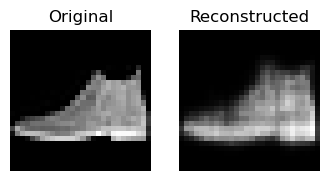

In [12]:
reconstructed = autoencoder.predict(x_test[:1])

plt.figure(figsize=(4, 2))
plt.subplot(1, 2, 1)
plt.imshow(x_test[0].reshape(28, 28), cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(reconstructed[0].reshape(28, 28), cmap="gray")
plt.title("Reconstructed")
plt.axis("off")
plt.show()